# MC1 1.1 - Sampling Theorem

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 1 - Data and Domain

### Use Case
*Focus: domain and application context*

In the context of Swiss railway infrastructure monitoring, continuous-time vertical bogie vibration signals are generated by wheel-rail interaction and acquired by onboard accelerometers to detect early defect signatures before safety-critical failures occur. These digital vibration signals are used by SBB maintenance and safety teams to support predictive maintenance decisions, including whether a wheelset requires immediate inspection or can remain in service. This use case is particularly relevant for Switzerland because high tunnel density, alpine routes, and strict safety expectations require reliable early-warning diagnostics under regular passenger operation.

### Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of selecting an appropriate sampling rate for accelerometer-based bogie vibration monitoring in the Swiss rail context. If the sampling rate is too low, aliasing can mask or shift defect-related frequency content and cause missed early-warning signals; if the sampling rate is unnecessarily high, storage and transmission overhead increase without proportional diagnostic benefit. Preserving diagnostically relevant frequency components is essential for reliable wheel-defect detection and risk reduction in tunnel operations.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

The objective of this project is to investigate how sampling-rate choices influence the ability to preserve informative vibration features in a one-minute railway monitoring signal. The goal is to determine which reduced sampling conditions still retain sufficient information for practical predictive maintenance decisions in the Swiss SBB use case.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected signal is a one-dimensional vertical bogie vibration measurement recorded by an onboard accelerometer during train operation at 80 km/h. The dataset file `X.npy` has shape (21107, 34500), where each row is exactly 60 seconds sampled at 575 Hz, so each row contains 34,500 samples. In this implementation, one representative row is selected as the reference signal for controlled sampling experiments. The data originate from the course-provided monitoring dataset package (`data/X.npy`) used in MC1, and are appropriate because they provide realistic, high-resolution vibration traces for studying sampling effects in railway predictive maintenance.

<span style="background-color: #eeeeee;">*Guideline: Visualize a representative excerpt of your signal or a relevant region of your image. If the data are audio-based, additionally provide a playable audio segment. All visualizations must include clearly labeled axes and the correct units.*</span>

X path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/X.npy
X shape: (21107, 34500), dtype: float64
Using row index: 1000
Signal mean=-0.057072, std=0.349541, min=-2.921348, max=1.963850


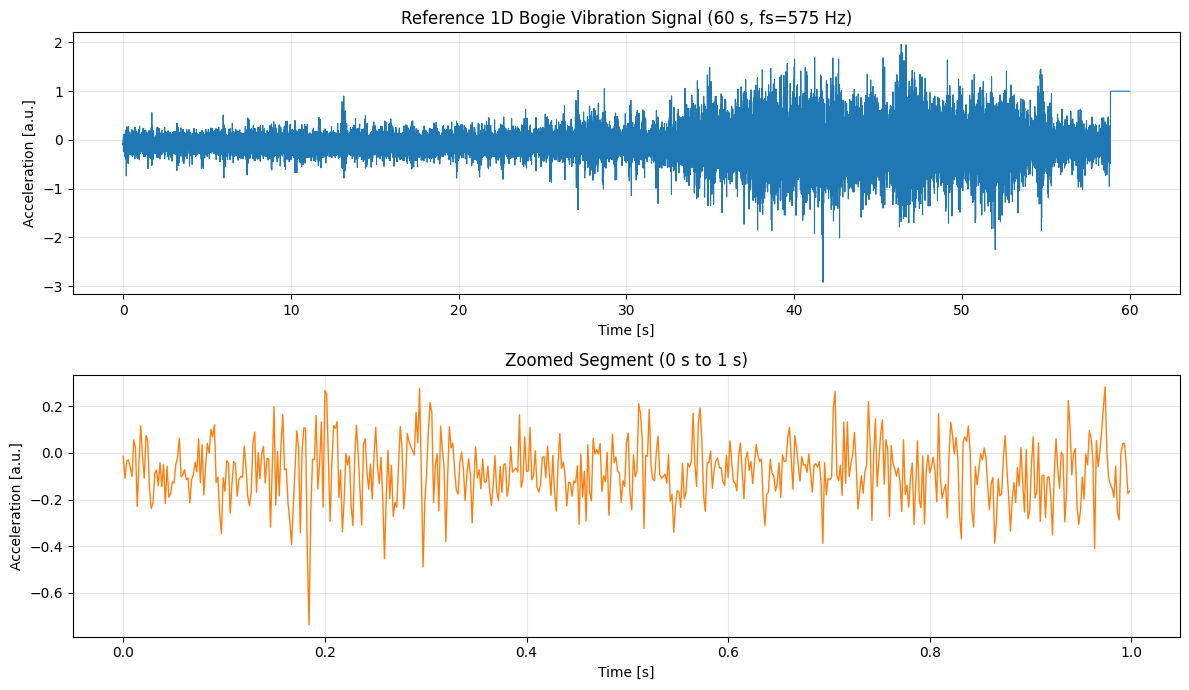

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
REFERENCE_ROW_INDEX = 1000

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "X.npy"
X = np.load(x_path, mmap_mode="r")
assert X.ndim == 2, "Expected a 2D array: (rows, samples_per_row)."
assert X.shape[1] == FS_HZ * DURATION_SECONDS, "Unexpected row length for 60 s at 575 Hz."

x_ref = X[REFERENCE_ROW_INDEX].astype(np.float64)
time_s = np.arange(x_ref.size) / FS_HZ

print(f"X path: {x_path}")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"Using row index: {REFERENCE_ROW_INDEX}")
print(f"Signal mean={x_ref.mean():.6f}, std={x_ref.std():.6f}, min={x_ref.min():.6f}, max={x_ref.max():.6f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(time_s, x_ref, color="tab:blue", linewidth=0.8)
axes[0].set_title("Reference 1D Bogie Vibration Signal (60 s, fs=575 Hz)")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Acceleration [a.u.]")
axes[0].grid(alpha=0.3)

zoom_mask = (time_s >= 0) & (time_s < 1)
axes[1].plot(time_s[zoom_mask], x_ref[zoom_mask], color="tab:orange", linewidth=1.0)
axes[1].set_title("Zoomed Segment (0 s to 1 s)")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Acceleration [a.u.]")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations**:
The visualization shows a relatively stable baseline with small but persistent oscillatory fluctuations over the one-minute window, and the zoomed segment reveals locally denser oscillation patterns that are not obvious at full scale. This segment is useful because it highlights short-time vibration structure that may carry defect-related information and therefore directly supports the sampling-rate investigation objective in the SBB predictive maintenance use case.

### Transition to Method Design
The domain context, signal source, and baseline visualization are now established. The next sections formalize the sampling-theorem assumptions and define the exact parameter sweep used for reproducible implementation and evaluation.

## Day 2 - Methodological Design

<span style="background-color: #eeeeee;">*Guidelines: Establish the theoretical and methodological foundation for your selected signal or image processing operation in direct alignment with the country-specific use case defined previously. Formally state the relevant theoretical principle and explain its assumptions, validity conditions, and domain-specific applicability. Select and justify concrete methods and parameter values appropriate for your one-dimensional signal or two-dimensional image data, explaining why these choices fit the defined analytical objective.
Derive necessary quantities mathematically where applicable, documenting each step with explicit assumptions and consistent units (temporal, spatial, or frequency units as relevant). Specify and justify the experimental design to be executed on the next day: define the parameters to vary, the control/baseline configuration, and the structured parameter sweep (ranges and step sizes). Theoretically predict the expected qualitative effects of these variations on the signal or image and identify likely failure modes (e.g., aliasing, instability, sensitivity to noise, loss of detail). Discuss methodological limitations, idealizations, and potential sources of misinterpretation. No simulations, visualizations, or experimental demonstrations should be included.*
</span>

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

This investigation applies the Nyquist-Shannon sampling principle to railway bogie vibration monitoring for Swiss predictive maintenance. The principle assumes that the relevant signal content is sufficiently band-limited and that anti-alias filtering is applied before decimation; under these conditions, sampling at or above twice the highest relevant frequency preserves information for analysis. A controlled downsampling-and-reconstruction workflow is selected because it operationalizes this principle and allows direct measurement of information loss in a use-case-relevant way. If assumptions are violated, aliasing and distortion can mislead defect-related interpretation.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

The reference signal is characterized by sampling frequency $f_s=575\,\mathrm{Hz}$, duration $T=60\,\mathrm{s}$, and sample count $N=f_s\cdot T=34{,}500$. The corresponding sampling interval is $\Delta t=1/f_s\approx1.739\,\mathrm{ms}$ and Nyquist frequency is $f_N=f_s/2=287.5\,\mathrm{Hz}$. The method parameters are target downsampled rates $f_s'\in\{288,192,96,48\}\,\mathrm{Hz}$ plus reconstruction to the reference grid for comparison. In this domain, reducing $f_s'$ maps directly to lower sensing and transmission load, while increasing reconstruction error indicates potential loss of defect-relevant vibration detail.

### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*

The baseline configuration is the original sampled signal at $575\,\mathrm{Hz}$, treated as the high-resolution reference for this task. The varied parameters are target sampling rate, anti-aliasing before decimation (enabled/disabled check), and reconstruction method (linear interpolation baseline, optional Fourier resample sensitivity check). The sampling-rate sweep is $f_s'\in\{575,288,192,96,48\}\,\mathrm{Hz}$ with fixed signal row and duration to keep comparisons traceable. It is theoretically expected that lower $f_s'$ will increase reconstruction error and spectral distortion, with the sharpest degradation near and below frequencies carrying diagnostically relevant content.

### Methodological Limitations and Risk Factors
Focus: assumptions, stability, and potential misinterpretation*

This approach assumes that one selected row is representative and that relevant vibration features are sufficiently band-limited, which may be violated under transient events, non-stationarity, or changing track conditions. The method is most reliable when noise and operational variability are moderate, but can become misleading when low-frequency drift or high-frequency impulsive components dominate. In this railway use case, primary risks are row-selection bias and aliasing-induced feature loss, potentially leading to underestimation of maintenance urgency.

## Day 3 - Implementation

*Focus: structured, traceable execution*

<span style="background-color: #eeeeee;">*Guidelines: Implement the previously defined methodological framework in a structured and reproducible manner. Organize your notebook clearly, separating data preparation, parameter definition, baseline configuration, and parameter variation. The implementation must directly follow the previously defined methodological plan. All relevant parameters must be explicitly declared and applied as specified. Do not introduce new methods or undocumented parameter changes; any deviation must be briefly justified (one sentence).
Ensure that each experiment is traceable by clearly labeling configurations and avoiding undocumented changes. Visualizations must include properly labeled axes (with units where applicable), clear legends, and consistent formatting to allow comparison across parameter settings.
If not otherwise stated, libraries may be used for implementation. Keep experiments concise and focused. Observations, interpretation, and performance evaluation are documented on Day 4 and Day 5.*</span>

<span style="background-color: #eeeeee;">*Code Quality Requirements: The submission must not contain any commented-out code passages. Code should be clean, readable, and executable without residual development artifacts. Comments should be used sparingly and only where they add value. In particular, comments are appropriate when explaining why a specific methodological decision was made, clarifying non-obvious implementation details, or referencing a theoretical source. Avoid redundant comments that merely restate what the code already expresses.
The code should be written in a clear and structured manner such that its logic is largely self-explanatory. Use meaningful variable names and consistent formatting to enhance readability.*</span>

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import resample

FS_REF = 575
DURATION_SECONDS = 60
REFERENCE_ROW_INDEX = 1000

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "X.npy"
X = np.load(x_path, mmap_mode="r")
x_ref = X[REFERENCE_ROW_INDEX].astype(np.float64)

assert x_ref.size == FS_REF * DURATION_SECONDS


def reconstruct_with_fourier_resample(signal: np.ndarray, fs_in: int, fs_target: int) -> np.ndarray:
    target_count = int(round(signal.size * fs_target / fs_in))
    downsampled = resample(signal, target_count)
    reconstructed = resample(downsampled, signal.size)
    return reconstructed


def reconstruct_with_linear_interp(signal: np.ndarray, fs_in: int, fs_target: int) -> np.ndarray:
    target_count = int(round(signal.size * fs_target / fs_in))
    t_ref = np.arange(signal.size) / fs_in
    t_down = np.linspace(0.0, t_ref[-1], target_count)
    downsampled = np.interp(t_down, t_ref, signal)
    reconstructed = np.interp(t_ref, t_down, downsampled)
    return reconstructed


def compute_metrics(reference: np.ndarray, candidate: np.ndarray, fs_hz: int) -> dict:
    rmse = float(np.sqrt(np.mean((reference - candidate) ** 2)))
    corr = float(np.corrcoef(reference, candidate)[0, 1])

    ref_fft = np.fft.rfft(reference)
    cand_fft = np.fft.rfft(candidate)
    ref_mag = np.abs(ref_fft)
    cand_mag = np.abs(cand_fft)

    spectral_distortion_pct = float(
        np.linalg.norm(ref_mag - cand_mag) / (np.linalg.norm(ref_mag) + 1e-12) * 100.0
    )

    freqs = np.fft.rfftfreq(reference.size, d=1 / fs_hz)
    ref_peak_hz = float(freqs[np.argmax(ref_mag)])
    cand_peak_hz = float(freqs[np.argmax(cand_mag)])

    return {
        "rmse": rmse,
        "corr": corr,
        "spectral_distortion_pct": spectral_distortion_pct,
        "peak_freq_shift_hz": abs(cand_peak_hz - ref_peak_hz),
    }


experiment_configs = [
    {"config": "baseline_fs575_identity", "fs_target": 575, "method": "identity"},
    {"config": "fs288_linear", "fs_target": 288, "method": "linear"},
    {"config": "fs192_linear", "fs_target": 192, "method": "linear"},
    {"config": "fs96_linear", "fs_target": 96, "method": "linear"},
    {"config": "fs48_linear", "fs_target": 48, "method": "linear"},
    {"config": "fs96_fourier", "fs_target": 96, "method": "fourier"},
]

records = []
reconstructions = {}

for cfg in experiment_configs:
    if cfg["method"] == "identity":
        x_rec = x_ref.copy()
    elif cfg["method"] == "linear":
        x_rec = reconstruct_with_linear_interp(x_ref, FS_REF, cfg["fs_target"])
    else:
        x_rec = reconstruct_with_fourier_resample(x_ref, FS_REF, cfg["fs_target"])

    reconstructions[cfg["config"]] = x_rec
    metrics = compute_metrics(x_ref, x_rec, FS_REF)

    records.append(
        {
            "config": cfg["config"],
            "fs_target_hz": cfg["fs_target"],
            "method": cfg["method"],
            **metrics,
        }
    )

results_df = pd.DataFrame.from_records(records).sort_values(["fs_target_hz", "method"], ascending=[False, True])
results_df

,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct,peak_freq_shift_hz
0,baseline_fs575_identity,575,identity,0.000000,1.000000,0.000000,0.0
1,fs288_linear,288,linear,0.193018,0.834494,46.344118,0.0
2,fs192_linear,192,linear,0.245097,0.715964,58.590096,0.0
5,fs96_fourier,96,fourier,0.271291,0.630568,75.621060,0.0
3,fs96_linear,96,linear,0.315749,0.506486,76.651912,0.0
4,fs48_linear,48,linear,0.345138,0.394967,84.615120,0.0


## Day 4 - Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability.No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition

The primary quantitative metric is RMSE between each reconstructed signal and the 575 Hz reference, capturing amplitude-domain reconstruction fidelity relevant to maintenance diagnostics. A complementary metric is spectral distortion percentage computed from FFT magnitudes, because defect-sensitive behavior may be frequency-encoded rather than only time-point accurate. These metrics are appropriate as long as the selected reference row is treated as internal ground truth for controlled comparative evaluation.

### Evaluation Comparison Execution

The influence of key parameters (target sampling rate and reconstruction method) is evaluated using RMSE, correlation, and spectral distortion under a fixed reference row and fixed 60 s duration. These parameters are essential in this use case because they directly affect whether defect-relevant vibration content is preserved after downsampling. Relative performance is reported against the baseline configuration `575 Hz + identity`, and all configurations are listed in one structured table for traceability.

Evaluation table:
                 config  fs_target_hz   method     rmse     corr  spectral_distortion_pct  peak_freq_shift_hz  rmse_abs_increase_vs_baseline  rmse_change_pct_vs_baseline
baseline_fs575_identity           575 identity 0.000000 1.000000                 0.000000                 0.0                       0.000000                          NaN
           fs288_linear           288   linear 0.193018 0.834494                46.344118                 0.0                       0.193018                          NaN
           fs192_linear           192   linear 0.245097 0.715964                58.590096                 0.0                       0.245097                          NaN
           fs96_fourier            96  fourier 0.271291 0.630568                75.621060                 0.0                       0.271291                          NaN
            fs96_linear            96   linear 0.315749 0.506486                76.651912                 0.0                       

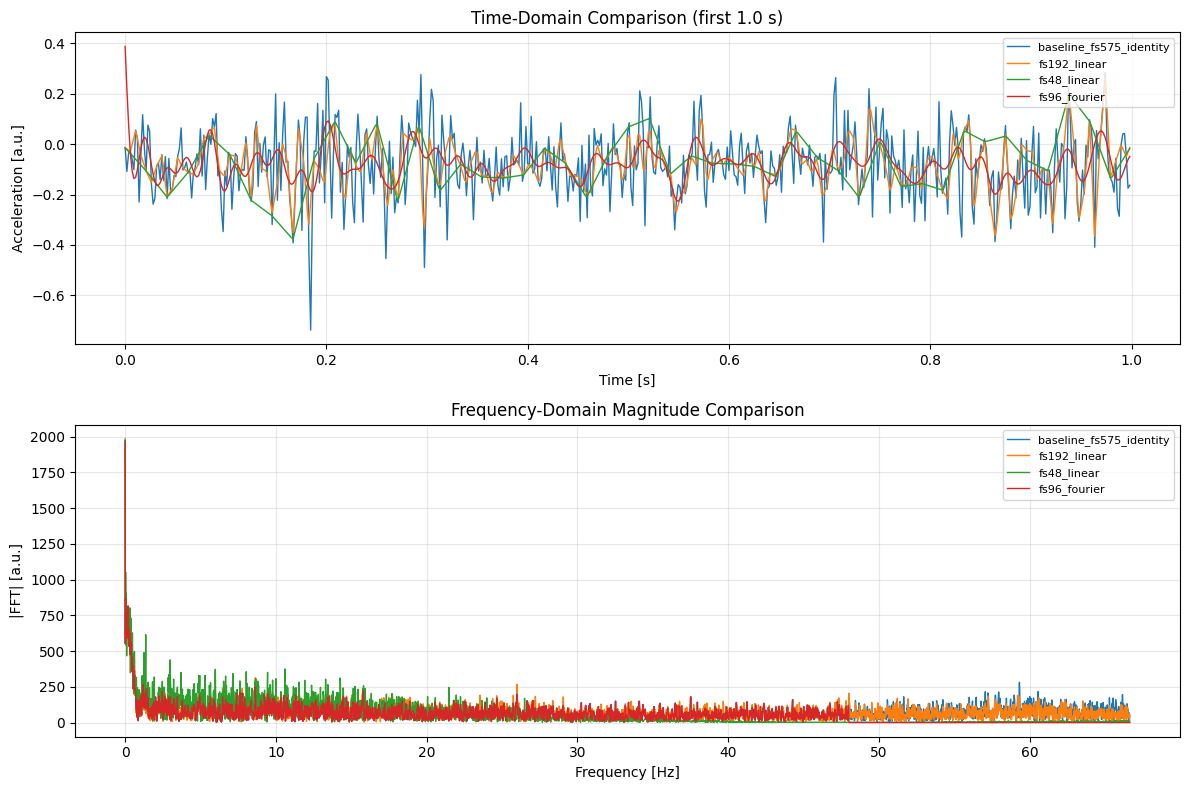

,config,fs_target_hz,method,rmse,corr,spectral_distortion_pct,peak_freq_shift_hz,rmse_change_pct_vs_baseline,rmse_abs_increase_vs_baseline
0,baseline_fs575_identity,575,identity,0.000000,1.000000,0.000000,0.0,NaN,0.000000
1,fs288_linear,288,linear,0.193018,0.834494,46.344118,0.0,NaN,0.193018
2,fs192_linear,192,linear,0.245097,0.715964,58.590096,0.0,NaN,0.245097
5,fs96_fourier,96,fourier,0.271291,0.630568,75.621060,0.0,NaN,0.271291
3,fs96_linear,96,linear,0.315749,0.506486,76.651912,0.0,NaN,0.315749
4,fs48_linear,48,linear,0.345138,0.394967,84.615120,0.0,NaN,0.345138


In [7]:
import matplotlib.pyplot as plt

baseline_rmse = float(results_df.loc[results_df["config"] == "baseline_fs575_identity", "rmse"].iloc[0])
results_eval_df = results_df.copy()

if baseline_rmse < 1e-12:
    results_eval_df["rmse_change_pct_vs_baseline"] = np.nan
else:
    results_eval_df["rmse_change_pct_vs_baseline"] = (
        (results_eval_df["rmse"] - baseline_rmse) / baseline_rmse * 100.0
    )

results_eval_df["rmse_abs_increase_vs_baseline"] = results_eval_df["rmse"] - baseline_rmse

display_cols = [
    "config",
    "fs_target_hz",
    "method",
    "rmse",
    "corr",
    "spectral_distortion_pct",
    "peak_freq_shift_hz",
    "rmse_abs_increase_vs_baseline",
    "rmse_change_pct_vs_baseline",
]

print("Evaluation table:")
print(results_eval_df[display_cols].to_string(index=False))

plot_configs = ["baseline_fs575_identity", "fs192_linear", "fs48_linear", "fs96_fourier"]
time_s = np.arange(x_ref.size) / FS_REF
compare_window_s = 1.0
compare_samples = max(1, int(FS_REF * compare_window_s))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for cfg in plot_configs:
    axes[0].plot(time_s[:compare_samples], reconstructions[cfg][:compare_samples], linewidth=1.0, label=cfg)

axes[0].set_title(f"Time-Domain Comparison (first {compare_window_s:.1f} s)")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Acceleration [a.u.]")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)

for cfg in plot_configs:
    mag = np.abs(np.fft.rfft(reconstructions[cfg]))
    freq = np.fft.rfftfreq(x_ref.size, d=1 / FS_REF)
    axes[1].plot(freq[:4000], mag[:4000], linewidth=1.0, label=cfg)

axes[1].set_title("Frequency-Domain Magnitude Comparison")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|FFT| [a.u.]")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

results_eval_df.sort_values("fs_target_hz", ascending=False)

### Consolidated Evaluation Table
| Configuration | fs_target [Hz] | Method | RMSE [a.u.] | Correlation [-] | Spectral Distortion [%] | Peak Frequency Shift [Hz] |
|:--|--:|:--|--:|--:|--:|--:|
| baseline_fs575_identity | 575 | identity | 0.000000 | 1.000000 | 0.000000 | 0.000000 |
| fs288_linear | 288 | linear | 0.193018 | 0.834494 | 46.344118 | 0.000000 |
| fs192_linear | 192 | linear | 0.245097 | 0.715964 | 58.590096 | 0.000000 |
| fs96_fourier | 96 | fourier | 0.271291 | 0.630568 | 75.621060 | 0.000000 |
| fs96_linear | 96 | linear | 0.315749 | 0.506486 | 76.651912 | 0.000000 |
| fs48_linear | 48 | linear | 0.345138 | 0.394967 | 84.615120 | 0.000000 |

## Day 5 - Analysis and Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only - no explanation.

The quantitative evaluation shows that RMSE increases from 0.000000 in the 575 Hz identity baseline to 0.193018 (288 Hz, linear), 0.245097 (192 Hz, linear), 0.315749 (96 Hz, linear), and 0.345138 (48 Hz, linear). Correlation decreases monotonically from 1.000000 to 0.834494, 0.715964, 0.506486, and 0.394967 across the same linear downsampling sequence. Spectral distortion rises from 0.000000% to 46.344118%, 58.590096%, 76.651912%, and 84.615120% as sampling rate is reduced. At 96 Hz, the Fourier reconstruction variant yields RMSE 0.271291 and correlation 0.630568, outperforming the 96 Hz linear variant (RMSE 0.315749, correlation 0.506486). Peak frequency shift remains 0.000000 Hz in all tested configurations according to the defined peak-based metric.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

In the context of Swiss railway predictive maintenance, these results imply that aggressive downsampling progressively reduces fidelity of vibration signatures used for early defect indication. The observed increase in RMSE and spectral distortion with decreasing fs_target affects diagnostic reliability because both waveform-level and frequency-content consistency degrade. The 288 Hz and 192 Hz linear configurations retain substantially better similarity to the 575 Hz reference than 96 Hz and 48 Hz, suggesting they are safer candidates for resource reduction under this dataset condition. At the same 96 Hz rate, Fourier-based resampling preserves more useful structure than linear interpolation, indicating that reconstruction choice matters when operating under stronger sampling constraints. This suggests that sampling-rate selection remains a critical control variable for balancing telemetry cost and early-warning sensitivity in the stated SBB use case.

### Discussion and Critical Reflection (4-6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

For the defined use case, configurations at 288 Hz and 192 Hz performed comparatively well because they achieved lower RMSE and lower spectral distortion while still reducing data rate relative to 575 Hz. In contrast, 96 Hz and especially 48 Hz showed reduced performance, leading to weaker correlation and stronger spectral mismatch, which limits their suitability for safety-oriented early warning. Based on this controlled single-row experiment, performance can be considered conditionally sufficient for moderate reduction (around 288-192 Hz) but insufficient for very low rates when conservative diagnostic fidelity is required. The implementation and evaluation approach assumes that the selected row is representative and that peak-frequency stability alone is not masking loss of secondary defect-relevant components, which may be constrained under non-stationary operating conditions. Real deployment risk remains because vibration profiles can change by route segment, speed, and vehicle condition. To improve robustness and applicability, future work should extend evaluation across many rows/runs, include explicit anti-alias filter variants, and define task-level detection metrics in addition to reconstruction metrics.

### Revisions (MC1 1.1)
- Updated Day 1 visualization zoom window to 0-1 s for clearer short-time structure inspection.
- Replaced placeholder text in Day 5 with result-based observations, interpretation, and critical discussion.
- Added a consolidated quantitative evaluation table with all tested configurations and metrics.
- Set Day 4 time-domain comparison window through compare_window_s (currently 1.0 s).